In [1]:
# !pip install ale_py stable_baselines3
# !pip install --upgrade moviepy
# !pip install tensorboard

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
import ale_py
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3.common.env_util import make_atari_env

In [4]:
env_id = "ALE/Riverraid-v5"
env = make_atari_env(env_id,n_envs=1,seed=0)

In [5]:
obs = env.reset()
env.render()

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [110, 156,  66],
        [110, 156,  66],
        [110, 156,  66]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

In [6]:
episodes=32
# frames = []
reward_history_before = []
episodes_total_reward = 0

for episode  in range(episodes):
    obs = env.reset()
    done = False
    total_reward = 0
    while not done:
        action = env.action_space.sample()
        action = [action]
        obs,reward,done,info = env.step(action)
        total_reward += reward[0]
        # frames.append(env.render())
    episodes_total_reward += total_reward
    reward_history_before.append(total_reward)
    print(f"Before Training - Episode {episode+1} - Total Reward: {total_reward}")

print(f"Average Reward Before Training: {np.mean(reward_history_before)}")

Before Training - Episode 1 - Total Reward: 1.0
Before Training - Episode 2 - Total Reward: 1.0
Before Training - Episode 3 - Total Reward: 2.0
Before Training - Episode 4 - Total Reward: 1.0
Before Training - Episode 5 - Total Reward: 0.0
Before Training - Episode 6 - Total Reward: 1.0
Before Training - Episode 7 - Total Reward: 1.0
Before Training - Episode 8 - Total Reward: 1.0
Before Training - Episode 9 - Total Reward: 1.0
Before Training - Episode 10 - Total Reward: 1.0
Before Training - Episode 11 - Total Reward: 1.0
Before Training - Episode 12 - Total Reward: 1.0
Before Training - Episode 13 - Total Reward: 1.0
Before Training - Episode 14 - Total Reward: 1.0
Before Training - Episode 15 - Total Reward: 1.0
Before Training - Episode 16 - Total Reward: 2.0
Before Training - Episode 17 - Total Reward: 3.0
Before Training - Episode 18 - Total Reward: 1.0
Before Training - Episode 19 - Total Reward: 2.0
Before Training - Episode 20 - Total Reward: 2.0
Before Training - Episode 21 

In [7]:
from stable_baselines3 import PPO,A2C
from stable_baselines3.common.evaluation import evaluate_policy
main_dir ="./" #"/content/drive/MyDrive/husob/06 ReinForcement Learning/008 Atari"
id=env_id.split("/")[-1]
total_steps = 500000


In [8]:
# To force CUDA
model_PPO = PPO("CnnPolicy", env, verbose=0, tensorboard_log=main_dir, device="cuda")
model_PPO.learn(total_timesteps=total_steps,progress_bar=True)
model_PPO.save(f"{main_dir}/PPO_{id}_{total_steps}")


Output()

In [17]:
episodes=32
# frames = []
reward_history_after_PPO = []
episodes_total_reward = 0

for episode  in range(episodes):
    obs = env.reset()
    done = False
    total_reward = 0
    while not done:
        action = model_PPO.predict(obs)[0]
        obs,reward,done,info = env.step(action)
        total_reward += reward[0]
        # frames.append(env.render())
    episodes_total_reward += total_reward
    reward_history_after_PPO.append(total_reward)
    print(f"aftere Training - Episode {episode+1} - Total Reward: {total_reward}")

print(f"Average Reward after Training: {np.mean(reward_history_after_PPO)}")

aftere Training - Episode 1 - Total Reward: 15.0
aftere Training - Episode 2 - Total Reward: 0.0
aftere Training - Episode 3 - Total Reward: 1.0
aftere Training - Episode 4 - Total Reward: 13.0
aftere Training - Episode 5 - Total Reward: 1.0
aftere Training - Episode 6 - Total Reward: 0.0
aftere Training - Episode 7 - Total Reward: 0.0
aftere Training - Episode 8 - Total Reward: 18.0
aftere Training - Episode 9 - Total Reward: 1.0
aftere Training - Episode 10 - Total Reward: 6.0
aftere Training - Episode 11 - Total Reward: 0.0
aftere Training - Episode 12 - Total Reward: 15.0
aftere Training - Episode 13 - Total Reward: 1.0
aftere Training - Episode 14 - Total Reward: 2.0
aftere Training - Episode 15 - Total Reward: 0.0
aftere Training - Episode 16 - Total Reward: 14.0
aftere Training - Episode 17 - Total Reward: 3.0
aftere Training - Episode 18 - Total Reward: 1.0
aftere Training - Episode 19 - Total Reward: 0.0
aftere Training - Episode 20 - Total Reward: 17.0
aftere Training - Episo

In [ ]:
model_A2C = A2C("CnnPolicy",env,verbose=0,tensorboard_log=main_dir)
model_A2C.learn(total_timesteps=total_steps,progress_bar=True)


Output()

NameError: name 'model' is not defined

In [12]:
model_A2C.save(f"{main_dir}/A2C_{id}_{total_steps}")

In [16]:
episodes=32
# frames = []
reward_history_after_A2C = []
episodes_total_reward = 0

for episode  in range(episodes):
    obs = env.reset()
    done = False
    total_reward = 0
    while not done:
        action = model_A2C.predict(obs)[0]
        obs,reward,done,info = env.step(action)
        total_reward += reward[0]
        # frames.append(env.render())
    episodes_total_reward += total_reward
    reward_history_after_A2C.append(total_reward)
    print(f"aftere Training - Episode {episode+1} - Total Reward: {total_reward}")

print(f"Average Reward after Training: {np.mean(reward_history_after_A2C)}")

aftere Training - Episode 1 - Total Reward: 1.0
aftere Training - Episode 2 - Total Reward: 23.0
aftere Training - Episode 3 - Total Reward: 0.0
aftere Training - Episode 4 - Total Reward: 9.0
aftere Training - Episode 5 - Total Reward: 1.0
aftere Training - Episode 6 - Total Reward: 2.0
aftere Training - Episode 7 - Total Reward: 2.0
aftere Training - Episode 8 - Total Reward: 2.0
aftere Training - Episode 9 - Total Reward: 2.0
aftere Training - Episode 10 - Total Reward: 2.0
aftere Training - Episode 11 - Total Reward: 19.0
aftere Training - Episode 12 - Total Reward: 15.0
aftere Training - Episode 13 - Total Reward: 0.0
aftere Training - Episode 14 - Total Reward: 0.0
aftere Training - Episode 15 - Total Reward: 5.0
aftere Training - Episode 16 - Total Reward: 13.0
aftere Training - Episode 17 - Total Reward: 0.0
aftere Training - Episode 18 - Total Reward: 0.0
aftere Training - Episode 19 - Total Reward: 1.0
aftere Training - Episode 20 - Total Reward: 4.0
aftere Training - Episode

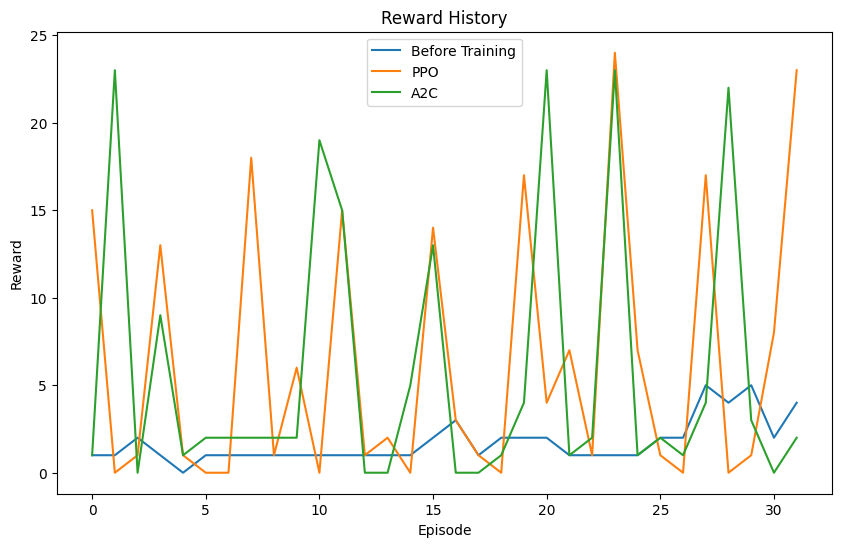

In [18]:
plt.figure(figsize=(10,6))
plt.plot(reward_history_before,label="Before Training")
plt.plot(reward_history_after_PPO,label="PPO")
plt.plot(reward_history_after_A2C,label="A2C")
plt.title("Reward History")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()